Dataset loaded successfully. Total rows to plot: 980
📊 Plots successfully generated and saved in: ../docs/bearing_features_trends.png


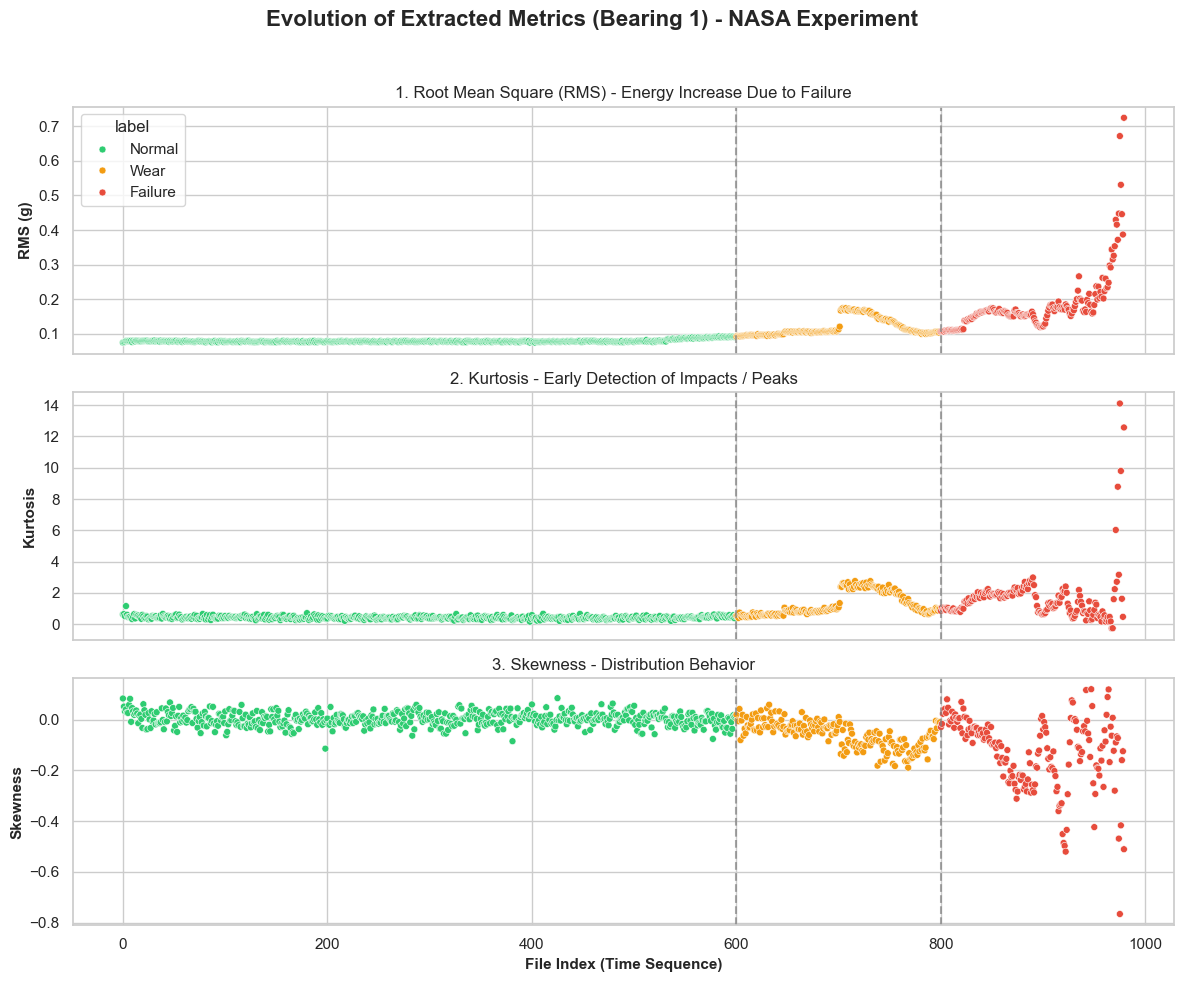

In [7]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# --- Data Loading ---
INPUT_CSV = '../data/processed/bearing_features_preprocessing.csv'

if not os.path.exists(INPUT_CSV):
    print(f"⚠️ The file {INPUT_CSV} does not exist. Please run the feature extraction cell first.")
else:
    df = pd.read_csv(INPUT_CSV)
    print(f"Dataset loaded successfully. Total rows to plot: {len(df)}")

    # --- Figure Configuration ---
    fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
    ax1, ax2, ax3 = axes[0], axes[1], axes[2]
    fig.suptitle(
        'Evolution of Extracted Metrics (Bearing 1) - NASA Experiment',
        fontsize=16,
        fontweight='bold'
    )

    # --- Color Palette ---
    palette = {'Normal': '#2ecc71', 'Wear': '#f39c12', 'Failure': '#e74c3c'}

    # --- Plot 1: RMS ---
    sns.scatterplot(
        data=df, x='file_id', y='b1_rms',
        hue='label', palette=palette,
        ax=ax1, s=25
    )
    ax1.set_ylabel('RMS (g)', fontsize=11, fontweight='bold')
    ax1.set_title('1. Root Mean Square (RMS) - Energy Increase Due to Failure', fontsize=12)
    ax1.axvline(x=600, color='gray', linestyle='--', alpha=0.7)
    ax1.axvline(x=800, color='gray', linestyle='--', alpha=0.7)

    # --- Plot 2: Kurtosis ---
    sns.scatterplot(
        data=df, x='file_id', y='b1_kurtosis',
        hue='label', palette=palette,
        ax=ax2, s=25
    )
    ax2.get_legend().remove()
    ax2.set_ylabel('Kurtosis', fontsize=11, fontweight='bold')
    ax2.set_title('2. Kurtosis - Early Detection of Impacts / Peaks', fontsize=12)
    ax2.axvline(x=600, color='gray', linestyle='--', alpha=0.7)
    ax2.axvline(x=800, color='gray', linestyle='--', alpha=0.7)

    # --- Plot 3: Skewness ---
    sns.scatterplot(
        data=df, x='file_id', y='b1_skewness',
        hue='label', palette=palette,
        ax=ax3, s=25
    )
    ax3.get_legend().remove()
    ax3.set_xlabel('File Index (Time Sequence)', fontsize=11, fontweight='bold')
    ax3.set_ylabel('Skewness', fontsize=11, fontweight='bold')
    ax3.set_title('3. Skewness - Distribution Behavior', fontsize=12)
    ax3.axvline(x=600, color='gray', linestyle='--', alpha=0.7)
    ax3.axvline(x=800, color='gray', linestyle='--', alpha=0.7)

    # Hide x-tick labels on upper subplots after all plots are drawn
    # (must be done after seaborn renders to avoid FixedFormatter warning)
    plt.setp(ax1.get_xticklabels(), visible=False)
    plt.setp(ax2.get_xticklabels(), visible=False)

    # --- Saving and Displaying ---
    plt.tight_layout(rect=(0, 0, 1, 0.96))

    os.makedirs('../docs', exist_ok=True)
    plt.savefig('../docs/bearing_features_trends.png', dpi=300, bbox_inches='tight')

    print("📊 Plots successfully generated and saved in: ../docs/bearing_features_trends.png")
    plt.show()
